<a href="https://colab.research.google.com/github/zydanne-costa/Ondas_ADCP_SCO_Mar_Nov_2025/blob/main/main_strk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BIBLIOTECAS

In [1]:
import pandas as pd
import numpy as np
import os
from glob import glob
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates

# DRIVE

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# WINDOW

In [3]:
def window(N, wt):

    nn = N - 1
    pn = 2 * np.pi * np.arange(0, nn + 1) / nn

    if wt[:4] == 'rect':
        w = np.ones(N)

    elif wt[:4] == 'tria':
        m = nn // 2
        w = np.arange(0, m + 1) / m
        w = np.concatenate([w, w[::-1][1:]])

    elif wt[:4] == 'hann':
        w = 0.5 * (1 - np.cos(pn))

    elif wt[:4] == 'hamm':
        w = 0.54 - 0.46 * np.cos(pn)

    elif wt[:4] == 'blac':
        w = (
            0.42
            - 0.5 * np.cos(pn)
            + 0.08 * np.cos(2 * pn)
        )

    else:
        raise ValueError('Tipo de janela inválido')

    return w

# WEIM

In [4]:
def weim(N, wt, x):

    w = window(N, wt)

    x = np.array(x).flatten()

    ln = (N - 1) // 2
    lx = len(x)
    lf = lx - ln

    y = np.zeros_like(x)

    for i in range(lx):

        # início
        if i < ln:

            y[i] = (
                np.sum(x[:ln+i+1] * w[ln-i:])
                / np.sum(w[ln-i:])
            )

        # centro
        elif i >= ln and i < lf:

            y[i] = (
                np.sum(x[i-ln:i+ln+1] * w)
                / np.sum(w)
            )

        # final
        else:

            y[i] = (
                np.sum(x[i-ln:] * w[:len(x[i-ln:])])
                / np.sum(w[:len(x[i-ln:])])
            )

    return y

# PROCESSAMENTO

In [5]:
#STRK

def processar_strk(
    caminho_pasta,
    nome_saida
):

    arquivos = sorted(
        glob(
            os.path.join(
                caminho_pasta,
                '*.txt'
            )
        )
    )

    lista_df = []

    for arq in arquivos:

        nome_arquivo = os.path.basename(arq)

        # =================================================
        # DATA
        # =================================================

        data_str = (
            nome_arquivo
            .replace('STrk', '')
            .replace('.txt', '')
        )

        data_inicial = pd.to_datetime(
            data_str,
            format='%Y%m%d%H%M%S%f'
        )

        # =================================================
        # LEITURA
        # =================================================

        dados = np.loadtxt(
            arq,
            comments='%'
        )

        # garantir matriz Nx4
        if dados.ndim == 1:

            continue

        # =================================================
        # INVÁLIDOS
        # =================================================

        dados[dados == 0] = np.nan

        dados[dados == -32768] = np.nan

        # =================================================
        # mm -> m
        # =================================================

        dados = dados / 1000

        # =================================================
        # DATAFRAME
        # =================================================

        dados = pd.DataFrame(
            dados,
            columns=[
                'B1_m',
                'B2_m',
                'B3_m',
                'B4_m'
            ]
        )

        # =================================================
        # INTERPOLAÇÃO
        # apenas gaps pequenos
        # =================================================

        for col in [
            'B1_m',
            'B2_m',
            'B3_m',
            'B4_m'
        ]:

            dados[col] = (
                dados[col]
                .interpolate(
                    limit=4
                )
            )

        # =================================================
        # REMOVER MARÉ
        # =================================================

        dados['B1_h'] = (
            dados['B1_m']
            - weim(
                275,
                'blac',
                dados['B1_m']
            )
        )

        dados['B2_h'] = (
            dados['B2_m']
            - weim(
                275,
                'blac',
                dados['B2_m']
            )
        )

        dados['B3_h'] = (
            dados['B3_m']
            - weim(
                275,
                'blac',
                dados['B3_m']
            )
        )

        dados['B4_h'] = (
            dados['B4_m']
            - weim(
                275,
                'blac',
                dados['B4_m']
            )
        )

        # =================================================
        # TEMPO ORIGINAL
        # 2 Hz = 0.5 s
        # =================================================

        tempo = pd.date_range(
            start=data_inicial,
            periods=len(dados),
            freq='500ms'
        )

        dados['DataHora'] = tempo

        # =================================================
        # DATAFRAME FINAL
        # =================================================

        dados_final = dados[
            [
                'DataHora',
                'B1_h',
                'B2_h',
                'B3_h',
                'B4_h'
            ]
        ]

        lista_df.append(
            dados_final
        )

    # =====================================================
    # CONCATENAR
    # =====================================================

    df_final = pd.concat(
        lista_df,
        ignore_index=True
    )

    # ordenar
    df_final = df_final.sort_values(
        'DataHora'
    )

    # reset índice
    df_final = df_final.reset_index(
        drop=True
    )

    # =====================================================
    # CORTES TEMPORAIS
    # =====================================================

    if nome_saida == 'Strk_CHU':

        inicio = pd.to_datetime(
            '2025-03-27 13:20:00'
        )

        fim = pd.to_datetime(
            '2025-04-02 16:00:00'
        )

        df_final = df_final[
            (
                df_final['DataHora']
                >= inicio
            )
            &
            (
                df_final['DataHora']
                <= fim
            )
        ]

    if nome_saida == 'Strk_SEC':

        inicio = pd.to_datetime(
            '2025-11-22 18:00:00'
        )

        fim = pd.to_datetime(
            '2025-11-30 09:00:00'
        )

        df_final = df_final[
            (
                df_final['DataHora']
                >= inicio
            )
            &
            (
                df_final['DataHora']
                <= fim
            )
        ]

        # =================================================
        # PADRONIZAR DURAÇÃO TEMPORAL
        # =================================================

        duracao_chu = (

            pd.to_datetime(
                '2025-04-02 16:00:00'
            )

            -

            pd.to_datetime(
                '2025-03-27 13:20:00'
            )

        )

        novo_fim = (
            inicio
            + duracao_chu
        )

        df_final = df_final[
            df_final['DataHora']
            <= novo_fim
        ]

    # =====================================================
    # RESET ÍNDICE
    # =====================================================

    df_final = df_final.reset_index(
        drop=True
    )

    # =====================================================
    # SALVAR CSV
    # =====================================================

    caminho_saida = (
        '/content/drive/MyDrive/'
        'Ondas/Dados/Refinados/'
        f'{nome_saida}.csv'
    )

    df_final.to_csv(
        caminho_saida,
        index=False,
        date_format='%Y-%m-%d %H:%M:%S.%f'
    )

    return df_final

# PROCESSAR DADOS

## Chuvoso

In [6]:
# CHUVOSO

caminho_chu = (
    '/content/drive/MyDrive/'
    'Ondas/Dados/marco2025/'
    'SCO1/Strk'
)

Strk_CHU = processar_strk(
    caminho_chu,
    'Strk_CHU'
)

## Menos Chuvosos

In [7]:
# MENOS CHUVOSO

caminho_sec = (
    '/content/drive/MyDrive/'
    'Ondas/Dados/novembro2025/'
    'SCO2/STrk_2'
)

Strk_SEC = processar_strk(
    caminho_sec,
    'Strk_SEC'
)


# 1o PLOT

## Formatação dos plots

In [8]:
plt.rcParams['font.family'] = 'serif'

# vírgula decimal

def comma_formatter(x, pos):

    return (
        f'{x:,.2f}'
        .replace('.', 'X')
        .replace(',', '.')
        .replace('X', ',')
    )

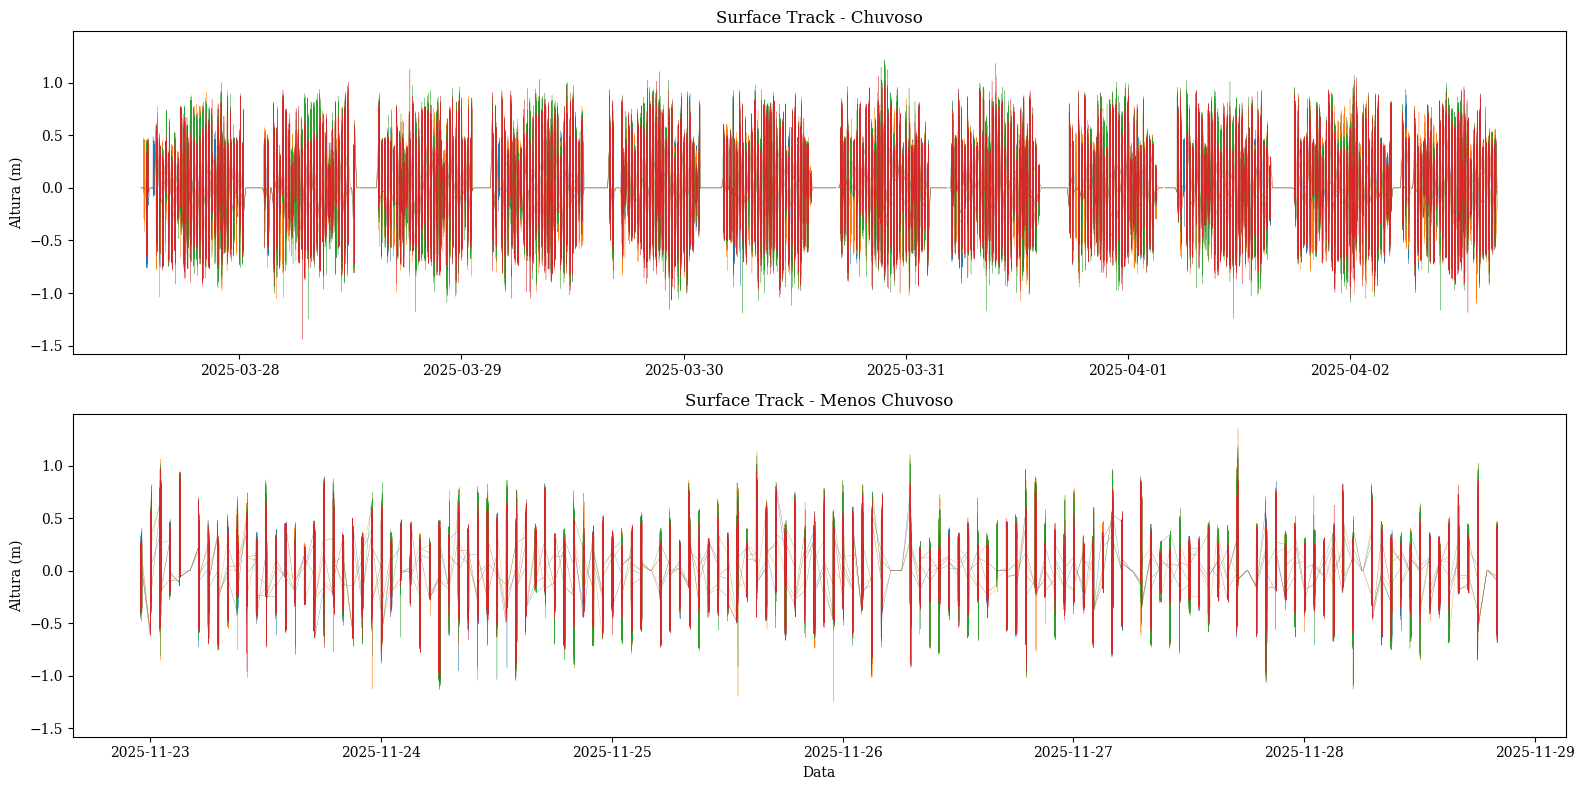

In [9]:
fig, ax = plt.subplots(
    2,
    1,
    figsize=(16,8),
    sharey=True
)

# =========================================================
# CHUVOSO
# =========================================================

for beam in [
    'B1_h',
    'B2_h',
    'B3_h',
    'B4_h'
]:

    ax[0].plot(
        Strk_CHU['DataHora'],
        Strk_CHU[beam],
        linewidth=0.2,
        label=beam
    )

ax[0].set_title(
    'Surface Track - Chuvoso'
)

ax[0].set_ylabel(
    'Altura (m)'
)

# =========================================================
# SECO
# =========================================================

for beam in [
    'B1_h',
    'B2_h',
    'B3_h',
    'B4_h'
]:

    ax[1].plot(
        Strk_SEC['DataHora'],
        Strk_SEC[beam],
        linewidth=0.2,
        label=beam
    )

ax[1].set_title(
    'Surface Track - Menos Chuvoso'
)

ax[1].set_ylabel(
    'Altura (m)'
)

ax[1].set_xlabel(
    'Data'
)

plt.tight_layout()
plt.show()


# DF Individuais

In [10]:
df_strk_chu = Strk_CHU.copy()

df_strk_sec = Strk_SEC.copy()

# datetime

df_strk_chu['DataHora'] = pd.to_datetime(
    df_strk_chu['DataHora']
)

df_strk_sec['DataHora'] = pd.to_datetime(
    df_strk_sec['DataHora']
)


# Identificando ondas

In [11]:
def individual_waves(serie):

    serie = np.array(serie)

    # remover NaN
    serie = serie[
        ~np.isnan(serie)
    ]

    cruz = np.where(

        (serie[:-1] < 0)

        &

        (serie[1:] >= 0)

    )[0]

    alturas = []

    for i in range(len(cruz)-1):

        trecho = serie[
            cruz[i]:cruz[i+1]
        ]

        if len(trecho) > 0:

            H = (
                np.max(trecho)
                - np.min(trecho)
            )

            alturas.append(H)

    return np.array(alturas)

# Def Hs

In [12]:
def calc_hs_beams(df):

    alturas_total = []

    beams = [
        'B1_h',
        'B2_h',
        'B3_h',
        'B4_h'
    ]

    for beam in beams:

        alturas = individual_waves(
            df[beam]
        )

        alturas_total.extend(
            alturas
        )

    alturas_total = np.array(
        alturas_total
    )

    if len(alturas_total) == 0:

        return np.nan

    # ordenar
    alturas_total = np.sort(
        alturas_total
    )[::-1]

    # 1/3 maiores
    n = int(
        len(alturas_total) / 3
    )

    if n == 0:

        return np.nan

    hs = np.mean(
        alturas_total[:n]
    )

    return hs

# Hs Geral

In [13]:
HsChu_strk = calc_hs_beams(
    df_strk_chu
)

HsSec_strk = calc_hs_beams(
    df_strk_sec
)

print(
    f'Hs STRK Chuvoso = '
    f'{HsChu_strk:.3f} m'
)

print(
    f'Hs STRK Seco = '
    f'{HsSec_strk:.3f} m'
)

Hs STRK Chuvoso = 0.755 m
Hs STRK Seco = 0.745 m


# Def intervalados

In [87]:
import numpy as np
# =========================================================
# Hs INTERVALADO
# =========================================================

def calc_hs_intervalo(df, intervalo):

    resultados = []

    grupos = df.resample(
        intervalo,
        on='DataHora'
    )

    for tempo, grupo in grupos:

        alturas_total = []

        # =============================================
        # CALCULAR ONDAS EM CADA BEAM
        # =============================================

        for beam in [
            'B1_h',
            'B2_h',
            'B3_h',
            'B4_h'
        ]:

            serie = (
                grupo[beam]
                .dropna()
            )

            if len(serie) > 10:

                alturas = individual_waves(
                    serie
                )

                alturas_total.extend(
                    alturas
                )

        # =============================================
        # CALCULAR Hs CONJUNTO
        # =============================================

        alturas_total = np.array(
            alturas_total
        )

        if len(alturas_total) > 0:

            alturas_total = np.sort(
                alturas_total
            )[::-1]

            n = int(
                len(alturas_total) / 3
            )

            if n > 0:

                hs = np.mean(
                    alturas_total[:n]
                )

                # Replace very small values with NaN
                if hs < 1e-10:
                    hs = np.nan

                resultados.append([
                    tempo,
                    hs
                ])

    df_hs = pd.DataFrame(
        resultados,
        columns=
            ['DataHora',
            'Hs'
        ]
    )

    return df_hs

# Hs 10min

In [88]:
df_Hs_10min_CHU_STRK = (
    calc_hs_intervalo(
        df_strk_chu,
        '10min'
    )
)

df_Hs_10min_SEC_STRK = (
    calc_hs_intervalo(
        df_strk_sec,
        '10min'
    )
)

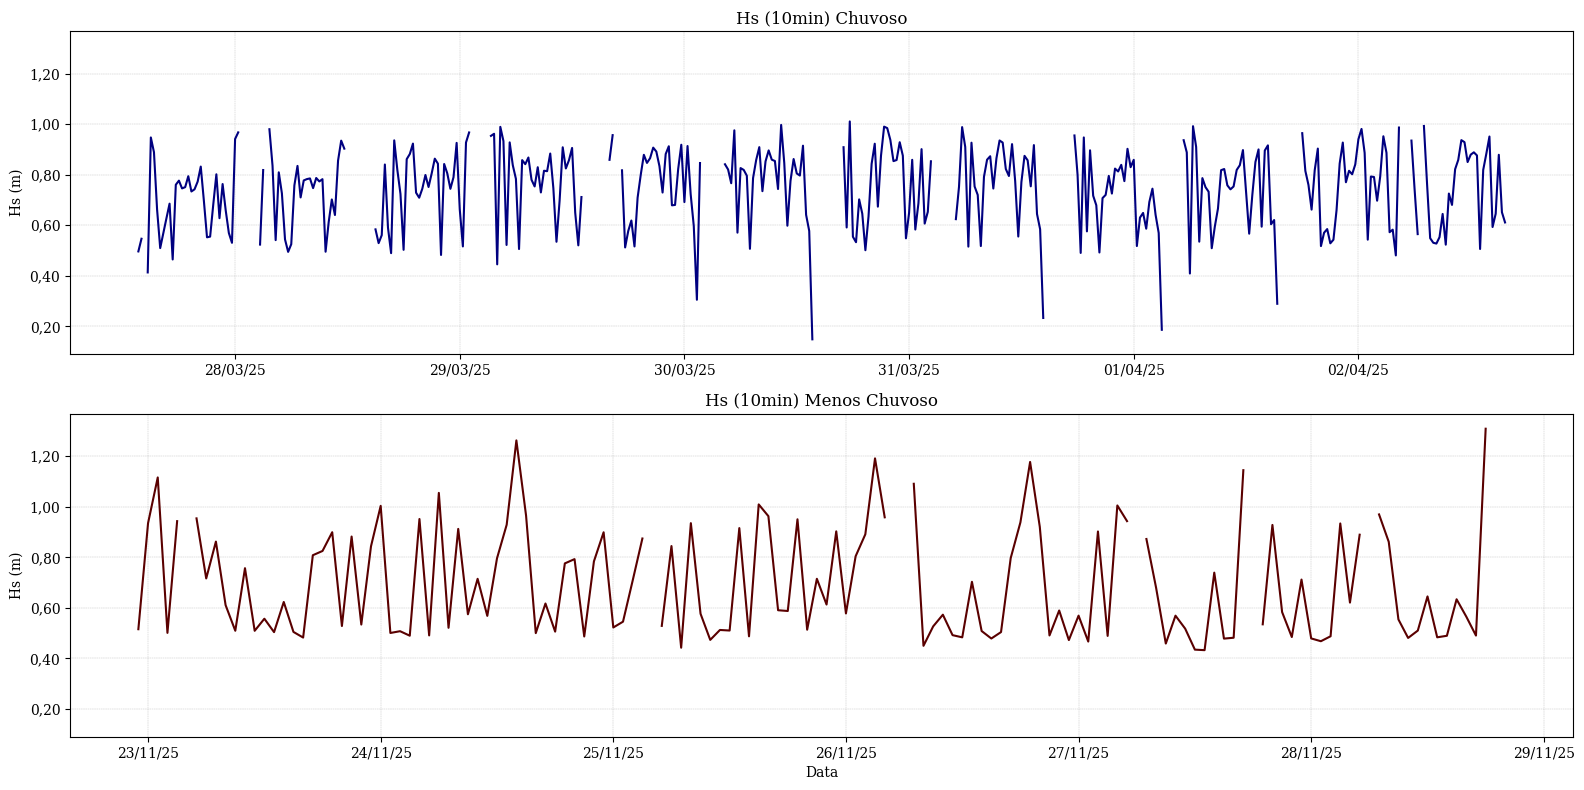

In [107]:
fig, ax = plt.subplots(
    2,
    1,
    figsize=(16,8),
    sharey=True
)

# chuvoso

ax[0].plot(
    df_Hs_10min_CHU_STRK['DataHora'],
    df_Hs_10min_CHU_STRK['Hs'],
    color='navy'
)

ax[0].set_title(
    'Hs (10min) Chuvoso'
)

ax[0].set_ylabel(
    'Hs (m)'
)

ax[0].grid(
    True,
    linestyle='--',
    linewidth=0.3,
    alpha=0.9
)

ax[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(
        comma_formatter
    )
)

# seco

ax[1].plot(
    df_Hs_10min_SEC_STRK['DataHora'],
    df_Hs_10min_SEC_STRK['Hs'],
    color='#5A0000'
)

ax[1].set_title(
    'Hs (10min) Menos Chuvoso'
)

ax[1].set_ylabel(
    'Hs (m)'
)

ax[1].set_xlabel(
    'Data'
)

ax[1].grid(
    True,
    linestyle='--',
    linewidth=0.3,
    alpha=0.9
)

ax[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(
        comma_formatter
    )
)

ax[0].xaxis.set_major_formatter(
    mdates.DateFormatter(
        '%d/%m/%y'
    )
)

ax[1].xaxis.set_major_formatter(
    mdates.DateFormatter(
        '%d/%m/%y'
    )
)

plt.tight_layout()
plt.show()

# Hs 30 mim

In [90]:
df_Hs_30min_CHU_STRK = (
    calc_hs_intervalo(
        df_strk_chu,
        '30min'
    )
)

df_Hs_30min_SEC_STRK = (
    calc_hs_intervalo(
        df_strk_sec,
        '30min'
    )
)


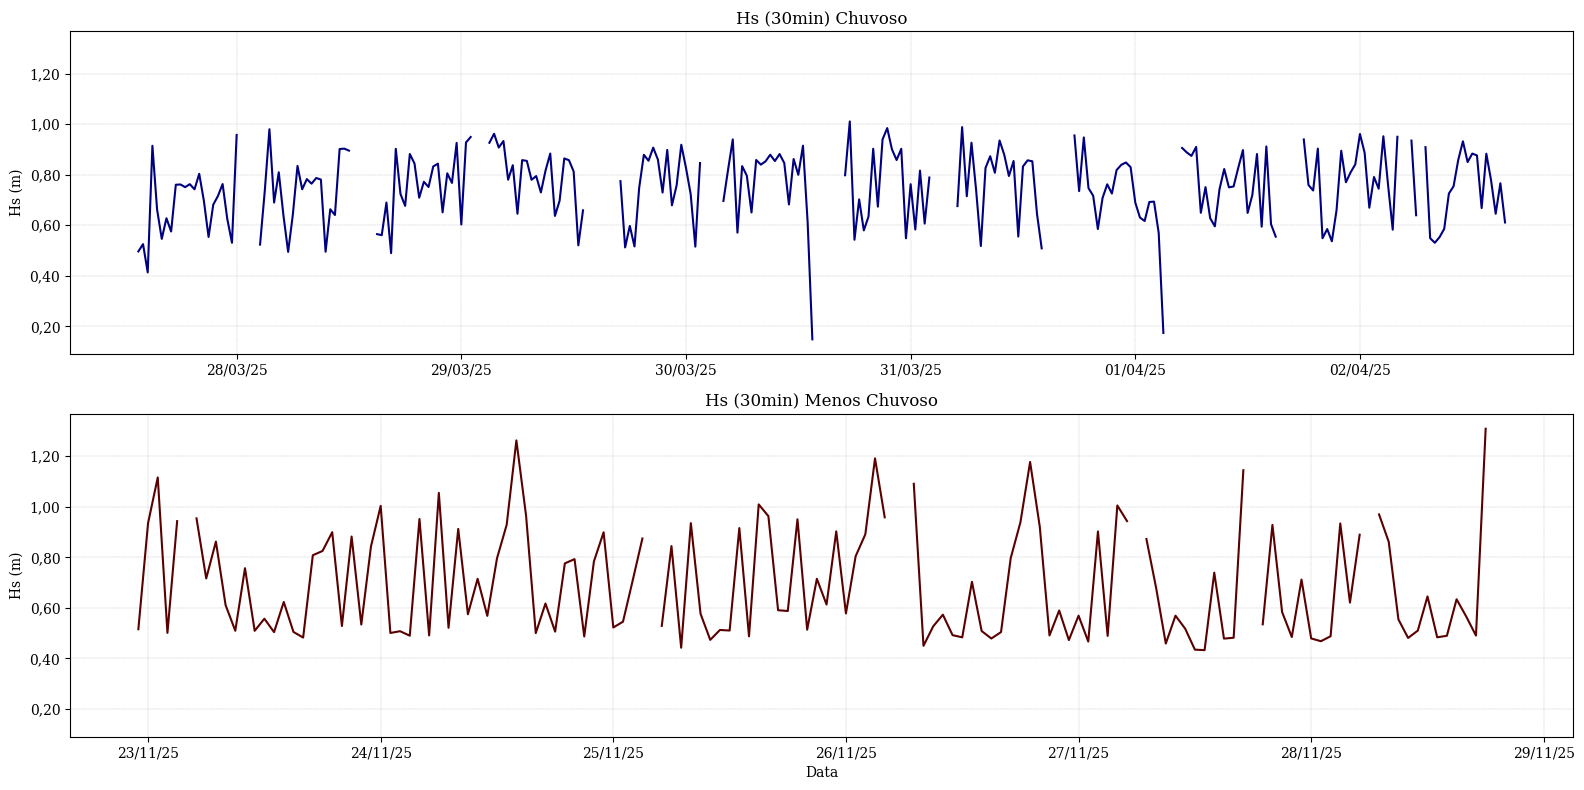

In [108]:
fig, ax = plt.subplots(
    2,
    1,
    figsize=(16,8),
    sharey=True
)

# =========================================================
# CHUVOSO
# =========================================================

ax[0].plot(
    df_Hs_30min_CHU_STRK['DataHora'],
    df_Hs_30min_CHU_STRK['Hs'],
    color='navy'
)

ax[0].set_title(
    'Hs (30min) Chuvoso'
)

ax[0].set_ylabel(
    'Hs (m)'
)

# grid discreto

ax[0].grid(
    True,
    linestyle='--',
    linewidth=0.3,
    alpha=0.9
)

# vírgula eixo y

ax[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(
        comma_formatter
    )
)

# =========================================================
# MENOS CHUVOSO
# =========================================================

ax[1].plot(
    df_Hs_30min_SEC_STRK['DataHora'],
    df_Hs_30min_SEC_STRK['Hs'],
    color='#5A0000'
)

ax[1].set_title(
    'Hs (30min) Menos Chuvoso'
)

ax[1].set_ylabel(
    'Hs (m)'
)

ax[1].set_xlabel(
    'Data'
)

# grid discreto

ax[1].grid(
    True,
    linestyle='--',
    linewidth=0.3,
    alpha=0.9
)

# vírgula eixo y

ax[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(
        comma_formatter
    )
)

# formato data

ax[0].xaxis.set_major_formatter(
    mdates.DateFormatter(
        '%d/%m/%y'
    )
)

ax[1].xaxis.set_major_formatter(
    mdates.DateFormatter(
        '%d/%m/%y'
    )
)

plt.tight_layout()
plt.show()

# Hs 1H

In [94]:
df_Hs_1H_CHU_STRK = (
    calc_hs_intervalo(
        df_strk_chu,
        '1H'
    )
)

df_Hs_1H_SEC_STRK = (
    calc_hs_intervalo(
        df_strk_sec,
        '1H'
    )
)

/tmp/ipykernel_4518/3383247696.py:10: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  grupos = df.resample(


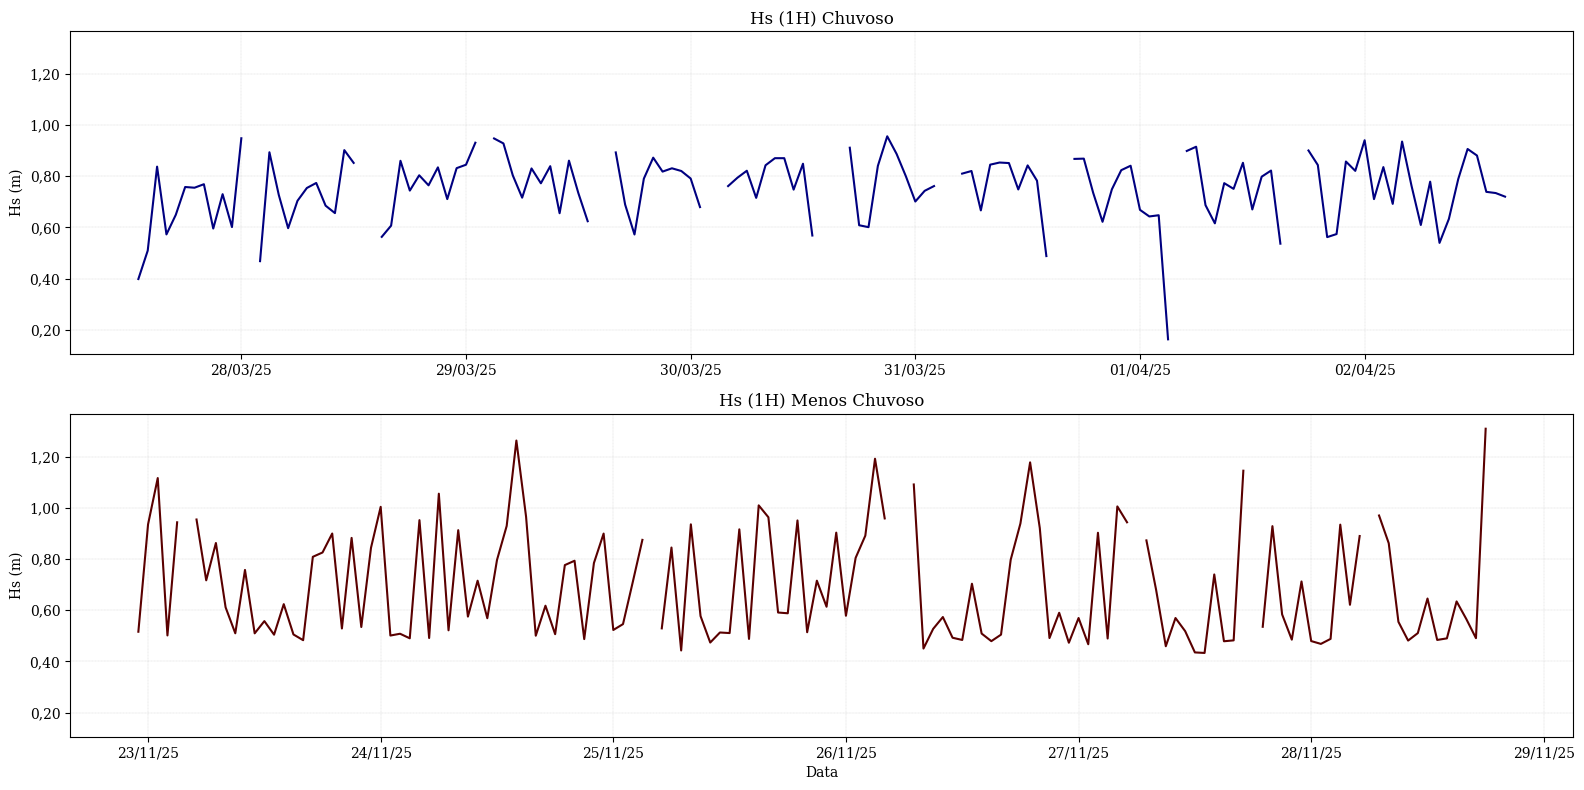

In [109]:
fig, ax = plt.subplots(
    2,
    1,
    figsize=(16,8),
    sharey=True
)

# chuvoso

ax[0].plot(
    df_Hs_1H_CHU_STRK['DataHora'],
    df_Hs_1H_CHU_STRK['Hs'],
    color='navy'
)

ax[0].set_title(
    'Hs (1H) Chuvoso'
)

ax[0].set_ylabel(
    'Hs (m)'
)

ax[0].grid(
    True,
    linestyle='--',
    linewidth=0.2,
    alpha=0.9
)

ax[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(
        comma_formatter
    )
)

# seco

ax[1].plot(
    df_Hs_1H_SEC_STRK['DataHora'],
    df_Hs_1H_SEC_STRK['Hs'],
    color='#5A0000'
)

ax[1].set_title(
    'Hs (1H) Menos Chuvoso'
)

ax[1].set_ylabel(
    'Hs (m)'
)

ax[1].set_xlabel(
    'Data'
)

ax[1].grid(
    True,
    linestyle='--',
    linewidth=0.2,
    alpha=0.9
)

ax[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(
        comma_formatter
    )
)

ax[0].xaxis.set_major_formatter(
    mdates.DateFormatter(
        '%d/%m/%y'
    )
)

ax[1].xaxis.set_major_formatter(
    mdates.DateFormatter(
        '%d/%m/%y'
    )
)

plt.tight_layout()
plt.show()

# Hs 3H

In [96]:
df_Hs_3H_CHU_STRK = (
    calc_hs_intervalo(
        df_strk_chu,
        '3H'
    )
)

df_Hs_3H_SEC_STRK = (
    calc_hs_intervalo(
        df_strk_sec,
        '3H'
    )
)

/tmp/ipykernel_4518/3383247696.py:10: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  grupos = df.resample(


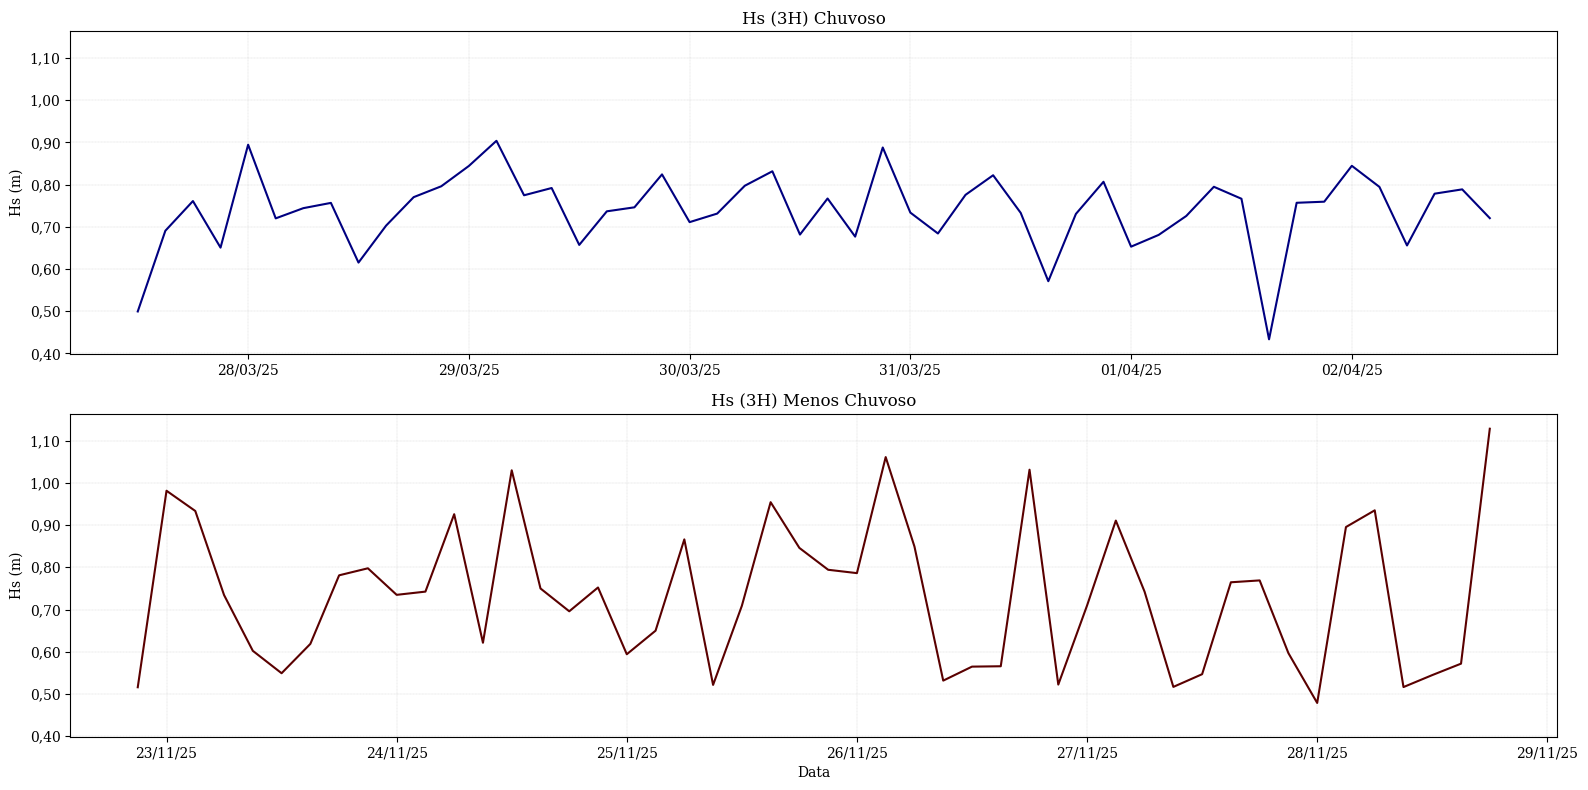

In [110]:
fig, ax = plt.subplots(
    2,
    1,
    figsize=(16,8),
    sharey=True
)

# chuvoso

ax[0].plot(
    df_Hs_3H_CHU_STRK['DataHora'],
    df_Hs_3H_CHU_STRK['Hs'],
    color='navy'
)

ax[0].set_title(
    'Hs (3H) Chuvoso'
)

ax[0].set_ylabel(
    'Hs (m)'
)

ax[0].grid(
    True,
    linestyle='--',
    linewidth=0.2,
    alpha=0.9
)

ax[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(
        comma_formatter
    )
)

# seco

ax[1].plot(
    df_Hs_3H_SEC_STRK['DataHora'],
    df_Hs_3H_SEC_STRK['Hs'],
    color='#5A0000'
)

ax[1].set_title(
    'Hs (3H) Menos Chuvoso'
)

ax[1].set_ylabel(
    'Hs (m)'
)

ax[1].set_xlabel(
    'Data'
)

ax[1].grid(
    True,
    linestyle='--',
    linewidth=0.2,
    alpha=0.9
)

ax[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(
        comma_formatter
    )
)

ax[0].xaxis.set_major_formatter(
    mdates.DateFormatter(
        '%d/%m/%y'
    )
)

ax[1].xaxis.set_major_formatter(
    mdates.DateFormatter(
        '%d/%m/%y'
    )
)

plt.tight_layout()
plt.show()

# Salvar arquivos

In [99]:
pasta_saida = (
    '/content/drive/MyDrive/'
    'Ondas/Dados/Refinados/'
)

# séries completas

Strk_CHU.to_csv(
    pasta_saida + 'Strk_CHU.csv',
    index=False
)

Strk_SEC.to_csv(
    pasta_saida + 'Strk_SEC.csv',
    index=False
)

# Hs 10 min

df_Hs_10min_CHU_STRK.to_csv(
    pasta_saida + 'Hs_10min_CHU.csv',
    index=False
)

df_Hs_10min_SEC_STRK.to_csv(
    pasta_saida + 'Hs_10min_SEC.csv',
    index=False
)

# Hs 30min

df_Hs_30min_CHU_STRK.to_csv(
    pasta_saida + 'Hs_30min_CHU.csv',
    index=False
)

df_Hs_30min_SEC_STRK.to_csv(
    pasta_saida + 'Hs_30min_SEC.csv',
    index=False
)


# Hs 1H

df_Hs_1H_CHU_STRK.to_csv(
    pasta_saida + 'Hs_1H_CHU.csv',
    index=False
)

df_Hs_1H_SEC_STRK.to_csv(
    pasta_saida + 'Hs_1H_SEC.csv',
    index=False
)

# Hs 3H

df_Hs_3H_CHU_STRK.to_csv(
    pasta_saida + 'Hs_3H_CHU.csv',
    index=False
)

df_Hs_3H_SEC_STRK.to_csv(
    pasta_saida + 'Hs_3H_SEC.csv',
    index=False
)

print(
    'Todos os arquivos foram salvos.'
)

Todos os arquivos foram salvos.


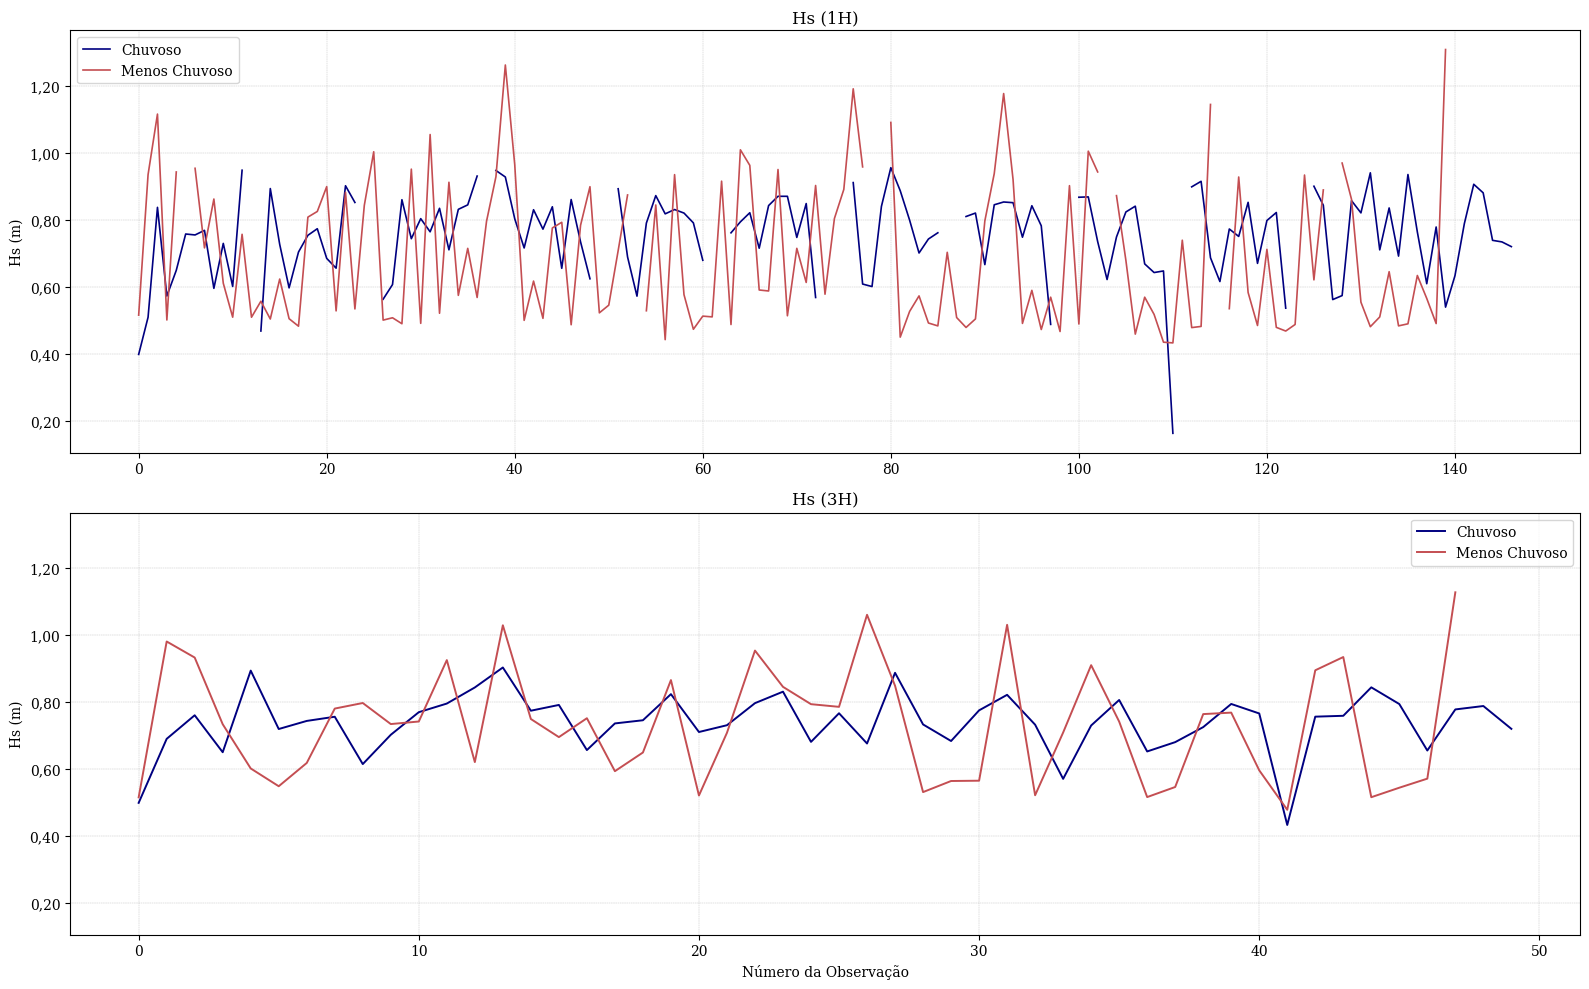

In [100]:
# =========================================================
# FIGURA COMPARATIVA
# SOMENTE Hs 1H E 3H
# =========================================================

fig, ax = plt.subplots(
    2,
    1,
    figsize=(16,10),
    sharey=True
)

# =========================================================
# ÍNDICES
# =========================================================

x_1h_chu = np.arange(
    len(df_Hs_1H_CHU_STRK)
)

x_1h_sec = np.arange(
    len(df_Hs_1H_SEC_STRK)
)

x_3h_chu = np.arange(
    len(df_Hs_3H_CHU_STRK)
)

x_3h_sec = np.arange(
    len(df_Hs_3H_SEC_STRK)
)

# =========================================================
# COR MENOS CHUVOSO
# =========================================================

cor_sec = '#C44E52'



# =========================================================
# Hs 1H
# =========================================================

ax[0].plot(
    x_1h_chu,
    df_Hs_1H_CHU_STRK['Hs'],
    color='navy',
    linewidth=1.2,
    label='Chuvoso'
)

ax[0].plot(
    x_1h_sec,
    df_Hs_1H_SEC_STRK['Hs'],
    color=cor_sec,
    linewidth=1.2,
    label='Menos Chuvoso'
)

ax[0].set_title(
    'Hs (1H)'
)

ax[0].set_ylabel(
    'Hs (m)'
)

ax[0].grid(
    True,
    linestyle='--',
    linewidth=0.3,
    alpha=0.9
)

ax[0].legend()

# =========================================================
# Hs 3H
# =========================================================

ax[1].plot(
    x_3h_chu,
    df_Hs_3H_CHU_STRK['Hs'],
    color='navy',
    linewidth=1.4,
    label='Chuvoso'
)

ax[1].plot(
    x_3h_sec,
    df_Hs_3H_SEC_STRK['Hs'],
    color=cor_sec,
    linewidth=1.4,
    label='Menos Chuvoso'
)

ax[1].set_title(
    'Hs (3H)'
)

ax[1].set_ylabel(
    'Hs (m)'
)

ax[1].set_xlabel(
    'Número da Observação'
)

ax[1].grid(
    True,
    linestyle='--',
    linewidth=0.3,
    alpha=0.9
)

ax[1].legend()

# =========================================================
# FORMATAÇÃO
# =========================================================

for eixo in ax:

    eixo.yaxis.set_major_formatter(
        mticker.FuncFormatter(
            comma_formatter
        )
    )

plt.tight_layout()
plt.show()


In [25]:
# verificando tamanho de dados
print(len(df_Hs_1H_CHU_STRK))
print(len(df_Hs_1H_SEC_STRK))

print(len(df_Hs_3H_CHU_STRK))
print(len(df_Hs_3H_SEC_STRK))

147
142
50
48


In [102]:
# =========================================================
# MENOR VALOR DE Hs EM CADA DF
# =========================================================

print(
    'Menor Hs 30min CHU:',
    df_Hs_30min_CHU_STRK['Hs'].min()
)

print(
    'Menor Hs 30min SEC:',
    df_Hs_30min_SEC_STRK['Hs'].min()
)

print(
    'Menor Hs 1H CHU:',
    df_Hs_1H_CHU_STRK['Hs'].min()
)

print(
    'Menor Hs 1H SEC:',
    df_Hs_1H_SEC_STRK['Hs'].min()
)

print(
    'Menor Hs 3H CHU:',
    df_Hs_3H_CHU_STRK['Hs'].min()
)

print(
    'Menor Hs 3H SEC:',
    df_Hs_3H_SEC_STRK['Hs'].min()
)

Menor Hs 30min CHU: 0.14853065480831823
Menor Hs 30min SEC: 0.43296372306550956
Menor Hs 1H CHU: 0.16294843322125943
Menor Hs 1H SEC: 0.43296372306550956
Menor Hs 3H CHU: 0.43342661222195283
Menor Hs 3H SEC: 0.47869455184513304


### Maior Valor de Hs em cada DF

In [103]:
print(
    'Maior Hs 30min CHU:',
    df_Hs_30min_CHU_STRK['Hs'].max()
)

print(
    'Maior Hs 30min SEC:',
    df_Hs_30min_SEC_STRK['Hs'].max()
)

print(
    'Maior Hs 1H CHU:',
    df_Hs_1H_CHU_STRK['Hs'].max()
)

print(
    'Maior Hs 1H SEC:',
    df_Hs_1H_SEC_STRK['Hs'].max()
)

print(
    'Maior Hs 3H CHU:',
    df_Hs_3H_CHU_STRK['Hs'].max()
)

print(
    'Maior Hs 3H SEC:',
    df_Hs_3H_SEC_STRK['Hs'].max()
)

Maior Hs 30min CHU: 1.010625230180304
Maior Hs 30min SEC: 1.3090872206607
Maior Hs 1H CHU: 0.9562895665966515
Maior Hs 1H SEC: 1.3090872206607
Maior Hs 3H CHU: 0.903687278823152
Maior Hs 3H SEC: 1.1282282330020235


In [104]:
# quantidade de NaN

print(
    df_Hs_1H_CHU_STRK['Hs'].isna().sum()
)

print(
    df_Hs_1H_SEC_STRK['Hs'].isna().sum()
)

print(
    df_Hs_3H_CHU_STRK['Hs'].isna().sum()
)

print(
    df_Hs_3H_SEC_STRK['Hs'].isna().sum()
)

18
8
0
0
